In [1]:
import os
import shutil
import pandas as pd
import numpy as np
from tqdm import tqdm

import cv2
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'

# Đường dẫn file nhãn (Ground Truth)
TRAIN_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_GroundTruth.csv')
TRAIN_META = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Metadata.csv')
TEST_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_GroundTruth.csv')

train_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

WORKING_DIR = ROOT_FOLDER
PROCESSED_DIR = '/kaggle/working/processed_images/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Tiền Xử Lý Ảnh

In [3]:
def dull_razor_and_enhance(image_path):
    # Đọc ảnh gốc
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- BƯỚC 1: XÓA LÔNG (Dull Razor - Lec 07: Morphological) ---
    # Chuyển sang ảnh xám để xử lý hình thái học
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Tạo cấu trúc phần tử (Structuring Element) - Lec 07, trang 3
    # Chúng ta dùng kernel 17x17 để quét các sợi lông
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))

    # Phép toán Black-hat: Giúp lấy ra các chi tiết tối (lông) trên nền sáng (da)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Tạo Mask (mặt nạ): Chuyển ảnh blackhat về nhị phân
    # Các sợi lông sẽ có màu trắng (255), vùng da có màu đen (0)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpainting: "Vá" ảnh. Thay thế các pixel trắng trong mask bằng
    # các pixel lân cận để xóa sợi lông một cách tự nhiên.
    img_clean = cv2.inpaint(img_rgb, mask, 1, cv2.INPAINT_TELEA)

    # --- BƯỚC 2: KHỬ NHIỄU (Lec 04: Spatial Filtering) ---
    # Dùng Median Filter (Lec 04, trang 35) để khử nhiễu muối tiêu và làm mịn da
    img_smooth = cv2.medianBlur(img_clean, 3)

    # --- BƯỚC 3: TĂNG CƯỜNG TƯƠNG PHẢN (Lec 03: Histogram Transformation) ---
    # Chuyển sang hệ màu LAB để chỉ tác động vào cường độ sáng (L)
    # mà không làm thay đổi màu sắc y tế của bệnh.
    lab = cv2.cvtColor(img_smooth, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Áp dụng CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    # Gộp lại và chuyển về RGB
    img_final = cv2.merge((l_enhanced, a, b))
    img_final = cv2.cvtColor(img_final, cv2.COLOR_LAB2RGB)

    return img_rgb, img_final

In [4]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']


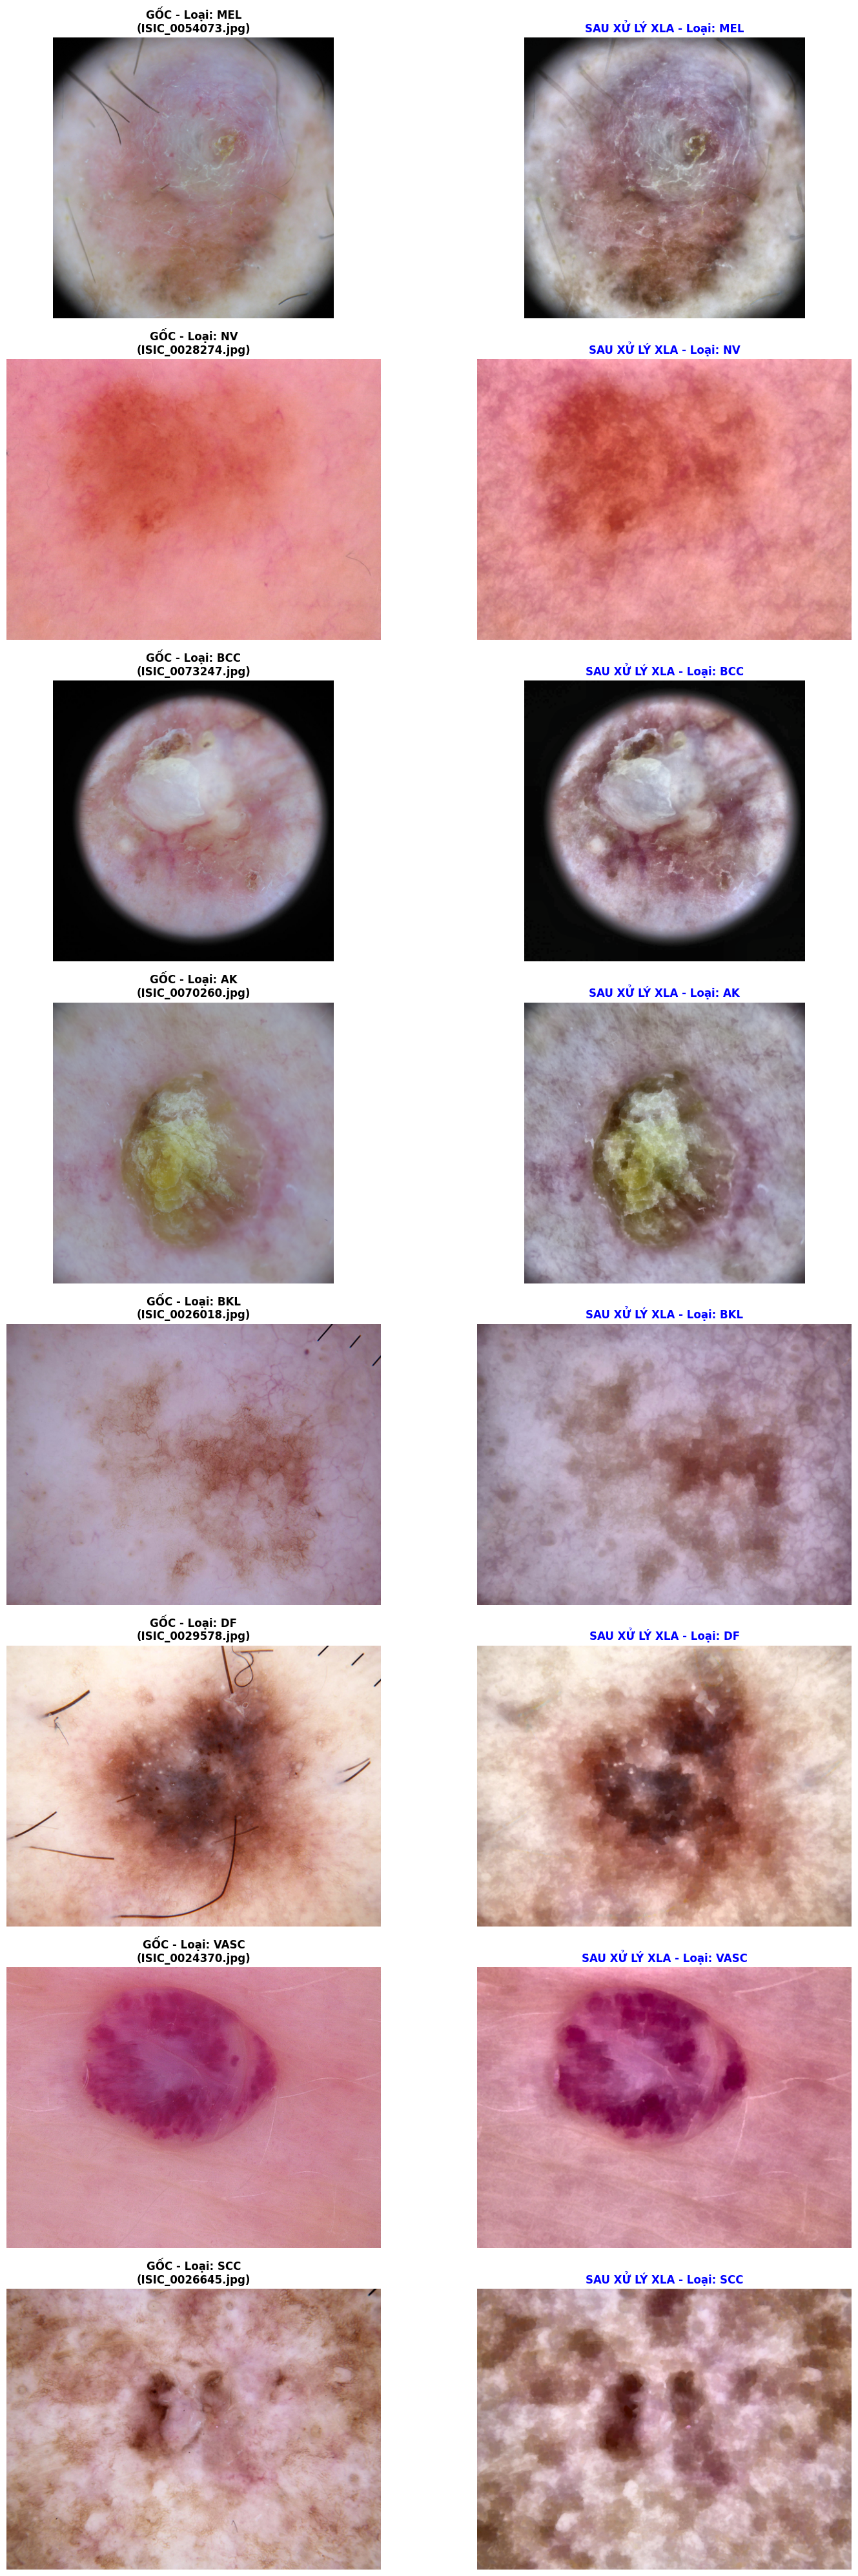

In [5]:
df_train = pd.read_csv(TRAIN_CSV)

def get_8_samples_by_class(df):
    sample_list = []
    for cls in classes:
        # Lọc các ảnh thuộc lớp này
        subset = df[df[cls] == 1.0]
        if not subset.empty:
            # Chọn ngẫu nhiên 1 ảnh
            img_id = subset.sample(1)['image'].values[0]
            # Đảm bảo có đuôi .jpg
            file_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
            sample_list.append((file_name, cls))
    return sample_list

# 3. THỰC HIỆN LẤY MẪU
samples = get_8_samples_by_class(df_train)

# 4. HIỂN THỊ KẾT QUẢ SO SÁNH (8 hàng x 2 cột)
plt.figure(figsize=(16, 40))

for i, (file_name, cls_name) in enumerate(samples):
    # Đường dẫn ảnh gốc trong folder đã giải nén
    path = os.path.join(train_img_folder, file_name)

    # Thực hiện tiền xử lý XLA
    orig, proc = dull_razor_and_enhance(path)

    if orig is not None:
        # Cột bên trái: Ảnh gốc
        plt.subplot(8, 2, 2*i + 1)
        plt.imshow(orig)
        plt.title(f"GỐC - Loại: {cls_name}\n({file_name})", fontsize=12, fontweight='bold')
        plt.axis('off')

        # Cột bên phải: Ảnh sau xử lý
        plt.subplot(8, 2, 2*i + 2)
        plt.imshow(proc)
        plt.title(f"SAU XỬ LÝ XLA - Loại: {cls_name}", fontsize=12, color='blue', fontweight='bold')
        plt.axis('off')
    else:
        print(f"⚠️ Không tìm thấy file: {path}")

plt.tight_layout()
plt.show()

In [ ]:
DEBUG_COUNT = 25000

df_full = pd.read_csv(TRAIN_CSV)
df_full = df_full[df_full['UNK'] != 1.0]
df_sample = df_full.sample(n=DEBUG_COUNT, random_state=42).copy()
df_sample['image_file'] = df_sample['image'].apply(lambda x: f"{x}.jpg")

# 3. LÀM SẠCH THƯ MỤC ĐẦU RA (Xóa cũ tạo mới)
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 4. VÒNG LẶP XỬ LÝ XLA (DIP)
print(f"🚀 Bắt đầu xử lý XLA cho {DEBUG_COUNT} ảnh...")

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    img_name = row['image_file']
    input_path = os.path.join(train_img_folder, img_name)
    output_path = os.path.join(PROCESSED_DIR, img_name)

    if os.path.exists(input_path):
        # Gọi hàm XLA đã định nghĩa (Dull Razor + Median + CLAHE)
        _, processed_img = dull_razor_and_enhance(input_path)

        if processed_img is not None:
            # Bước Sampling (Lec 02): Resize về 224x224
            processed_img_resized = cv2.resize(processed_img, (224, 224))
            # Lưu ảnh vật lý vào folder
            cv2.imwrite(output_path, cv2.cvtColor(processed_img_resized, cv2.COLOR_RGB2BGR))

print(f"\n✅ Xử lý xong! {len(os.listdir(PROCESSED_DIR))} ảnh sạch đã sẵn sàng tại: {PROCESSED_DIR}")

🚀 Bắt đầu xử lý XLA cho 25000 ảnh...


 45%|████▍     | 11171/25000 [14:28<15:52, 14.52it/s]

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Concatenate, GlobalAveragePooling2D, Dense, Dropout
import tensorflow.keras.backend as K

# 1. ĐỊNH NGHĨA LỚP SOFT ATTENTION (Đã sửa lỗi reduce_max và hỗ trợ Shape Inference)
class SoftAttention(Layer):
    def __init__(self, ch, m, **kwargs):
        self.channels = int(ch)
        self.multiheads = m
        super(SoftAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Khởi tạo trọng số cho tích chập 3D để tạo bản đồ chú ý
        # Hình dạng: (độ sâu, cao, rộng, kênh_vào, kênh_ra)
        self.conv_weight = self.add_weight(
            shape=(3, 3, 3, 1, self.multiheads),
            initializer='he_normal',
            trainable=True,
            name='at_conv_weight'
        )
        super(SoftAttention, self).build(input_shape)

    def call(self, x):
        # x shape: (batch, h, w, ch)

        # Mở rộng chiều để thực hiện Conv3D: (batch, h, w, ch, 1)
        input_x = tf.expand_dims(x, axis=-1)

        # 1. Tạo bản đồ chú ý (Attention Maps)
        # Thay thế K.conv3d bằng tf.nn.conv3d để ổn định hơn
        at_maps = tf.nn.conv3d(input_x, self.conv_weight, strides=[1, 1, 1, 1, 1], padding='SAME')

        # 2. Hoán vị và lấy Max (Sửa lỗi reduce_max tại đây)
        at_maps = tf.transpose(at_maps, perm=[0, 4, 1, 2, 3]) # (batch, multiheads, h, w, ch)
        at_maps = tf.reduce_max(at_maps, axis=-1)            # (batch, multiheads, h, w)

        # 3. Tính Softmax để lấy trọng số chú ý [0, 1]
        at_maps = tf.nn.softmax(at_maps)

        # 4. Nhân trọng số vào đặc trưng gốc
        at_maps = tf.expand_dims(at_maps, axis=-1)           # (batch, multiheads, h, w, 1)
        x_expanded = tf.expand_dims(x, axis=1)               # (batch, 1, h, w, ch)

        weighted_features = at_maps * x_expanded             # (batch, multiheads, h, w, ch)

        # 5. Cộng tổng các đầu chú ý (Multi-heads)
        focused_features = tf.reduce_sum(weighted_features, axis=1)
        return focused_features

    def compute_output_shape(self, input_shape):
        # Giúp Keras tự động hiểu kích thước đầu ra
        return input_shape

    def get_config(self):
        # Cho phép lưu và tải mô hình kèm lớp tùy chỉnh này
        config = super(SoftAttention, self).get_config()
        config.update({"ch": self.channels, "m": self.multiheads})
        return config

# 2. XÂY DỰNG MÔ HÌNH LAI (MOBILE NET V2 + ATTENTION)
def build_hybrid_model(num_classes=9):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = True

    inputs = base_model.input
    x = base_model.output

    # Lấy số lượng kênh đầu ra của MobileNetV2 (thường là 1280 ở lớp cuối)
    ch = x.shape[-1]

    # Thêm lớp chú ý (Attention) để tập trung vào vết bệnh
    attention_layer = SoftAttention(ch=ch, m=8, name='soft_attention')(x)

    # Kết hợp thông tin gốc và thông tin đã qua chú ý
    merged = Concatenate()([x, attention_layer])

    x = GlobalAveragePooling2D()(merged)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=predictions)
    return model

# 3. KHỞI TẠO MÔ HÌNH
model = build_hybrid_model(num_classes=8)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
label_columns = classes   # hoặc CLASSES nếu bạn đang dùng biến CLASSES ở phần trên

# ImageDataGenerator: ảnh đã qua tiền xử lý XLA rồi nên chỉ cần rescale
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_df, val_df = train_test_split(df_sample, test_size=0.2, random_state=42)

print(f"📊 Kiểm tra số lượng dòng trong Dataframe:")
print(f"- Tập Train: {len(train_df)} dòng")
print(f"- Tập Val: {len(val_df)} dòng")

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

In [ ]:
# 1. Các cơ chế giám sát (Callbacks)
callbacks = [
    # Dừng huấn luyện nếu độ chính xác trên tập Val không tăng sau 5 vòng (Epoch)
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    # Tự động giảm tốc độ học nếu mô hình bị kẹt (Lec 06)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),

    # Lưu lại phiên bản tốt nhất vào /kaggle/working để tải về sau khi chạy xong
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_hybrid_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 50

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // 32,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=len(val_df) // 32,
    callbacks=callbacks
)

#Test

In [ ]:
# --- 1. CẤU HÌNH ---
TEST_COUNT = 1000
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']   # 8 lớp, không có UNK
PROCESSED_FINAL_TEST_DIR = '/kaggle/working/final_test_images_real/'
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

print("🔄 Đang nạp file Ground Truth của tập Test...")
df_test_full = pd.read_csv(TEST_CSV)

# --- 2. LOẠI UNK NGAY TỪ ĐẦU, RỒI MỚI SAMPLE ---
df_test_no_unk = df_test_full[df_test_full['UNK'] != 1.0].copy()
print(f"Tổng mẫu test gốc: {len(df_test_full)} | Sau khi loại UNK: {len(df_test_no_unk)}")

df_test_sample = df_test_no_unk.sample(n=TEST_COUNT, random_state=42)
print(f"Đã lấy mẫu: {len(df_test_sample)} ảnh (100% thuộc 8 lớp đã biết)")

# --- 3. XỬ LÝ DIP ---
if os.path.exists(PROCESSED_FINAL_TEST_DIR):
    shutil.rmtree(PROCESSED_FINAL_TEST_DIR)
os.makedirs(PROCESSED_FINAL_TEST_DIR, exist_ok=True)

print(f"🛠️ Đang xử lý DIP (Dull Razor + CLAHE) cho {TEST_COUNT} mẫu test...")
for _, row in tqdm(df_test_sample.iterrows(), total=TEST_COUNT):
    img_id = row['image']
    input_path = os.path.join(test_img_folder, f"{img_id}.jpg")
    output_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")

    if os.path.exists(input_path):
        _, proc = dull_razor_and_enhance(input_path)
        if proc is not None:
            proc = cv2.resize(proc, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

# --- 4. DỰ ĐOÁN ---
y_true_closed, y_pred_closed = [], []
sample_confidences = []
sample_top_idx = []

print("\n🧠 AI đang dự đoán...")
for _, row in tqdm(df_test_sample.iterrows(), total=len(df_test_sample)):
    img_id = row['image']
    img_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)[0]
    top_idx = np.argmax(preds)
    confidence = preds[top_idx]

    true_idx = np.argmax(row[CLASSES].values)

    y_true_closed.append(true_idx)
    y_pred_closed.append(top_idx)
    sample_confidences.append(confidence)
    sample_top_idx.append(top_idx)

sample_confidences = np.array(sample_confidences)
sample_top_idx = np.array(sample_top_idx)

# --- 5. VẼ MA TRẬN NHẦM LẪN ---
print(f"\n📊 CLOSED-SET: {len(y_true_closed)} mẫu (100% thuộc 8 lớp đã biết, không lẫn UNK)")
plt.figure(figsize=(10, 8))
cm_closed = confusion_matrix(y_true_closed, y_pred_closed)
sns.heatmap(cm_closed, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'CLOSED-SET: KẾT QUẢ TRÊN {len(y_true_closed)} MẪU')
plt.xlabel('AI Dự Đoán')
plt.ylabel('Bác Sĩ Xác Nhận')
plt.show()

# --- 6. BÁO CÁO CHI TIẾT ---
print("\n📊 BÁO CÁO CHI TIẾT:")
present_labels = np.unique(np.concatenate((y_true_closed, y_pred_closed)))
present_names = [CLASSES[i] for i in present_labels]
print(classification_report(y_true_closed, y_pred_closed, labels=present_labels, target_names=present_names))

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

UNK_IDX = len(CLASSES)  # index 8, đại diện cho UNK trong CLASSES_WITH_UNK
CLASSES_WITH_UNK = CLASSES + ['UNK']

# Nhãn thật ở dạng open-set (cố định, không đổi theo threshold)
y_true_open = np.array([
    UNK_IDX if is_unk else true_idx
    for is_unk, true_idx in zip(sample_is_unk_true, sample_top_idx)  # placeholder, sửa dưới
])
# Sửa lại đúng: dùng true_idx_closed đã lưu, None nghĩa là UNK
y_true_open = np.array([
    UNK_IDX if is_unk else sample_true_idx_closed[i]
    for i, is_unk in enumerate(sample_is_unk_true)
])

thresholds = np.arange(0.3, 0.71, 0.05)  # 0.50, 0.55, 0.60, 0.65, 0.70
results = []

for th in thresholds:
    y_pred_open = np.where(sample_confidences < th, UNK_IDX, sample_top_idx)

    overall_acc = (y_pred_open == y_true_open).mean()
    f1_unk = f1_score(y_true_open, y_pred_open, labels=[UNK_IDX], average='macro', zero_division=0)
    precision_unk = precision_score(y_true_open, y_pred_open, labels=[UNK_IDX], average='macro', zero_division=0)
    recall_unk = recall_score(y_true_open, y_pred_open, labels=[UNK_IDX], average='macro', zero_division=0)
    f1_macro_all = f1_score(y_true_open, y_pred_open, average='macro', zero_division=0)

    results.append({
        'threshold': round(th, 2),
        'overall_acc': overall_acc,
        'f1_unk': f1_unk,
        'precision_unk': precision_unk,
        'recall_unk': recall_unk,
        'f1_macro_all': f1_macro_all
    })

df_threshold = pd.DataFrame(results)
print("\n📊 SWEEP THRESHOLD:")
print(df_threshold.to_string(index=False))

# Chọn threshold tốt nhất theo F1 tổng thể (macro, tính cả UNK)
best_row = df_threshold.loc[df_threshold['f1_macro_all'].idxmax()]
best_threshold = best_row['threshold']
print(f"\n✅ Threshold tốt nhất: {best_threshold} (F1 macro = {best_row['f1_macro_all']:.4f})")

# Biểu đồ threshold vs các chỉ số
plt.figure(figsize=(10, 6))
plt.plot(df_threshold['threshold'], df_threshold['overall_acc'], marker='o', label='Overall Accuracy')
plt.plot(df_threshold['threshold'], df_threshold['f1_unk'], marker='s', label='F1 (UNK)')
plt.plot(df_threshold['threshold'], df_threshold['f1_macro_all'], marker='^', label='F1 Macro (toàn bộ)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Ảnh hưởng của Threshold đến chất lượng Reject Option')
plt.legend()
plt.grid(alpha=0.3)
plt.show()